In [155]:
import numpy as np
import xarray as xr

In [156]:
from eofs.xarray import Eof

In [157]:
def eof(X,n=-1,detrend='constant',eof_in=None):
	"""Principal Component Analysis / Empirical Orthogonal Functions / SVD

		Uses Singular Value Decomposition to find the dominant modes of variability.
		The field X can be reconstructed with Y = dot(EOF,PC) + X.mean(axis=time)

		INPUTS:
			X	-- Field, shape (time x space).
			n	-- Number of modes to extract. All modes if n < 0
			detrend -- detrend with global mean ('constant')
						  or linear trend ('linear')
		    eof_in  -- If not None, compute PC by projecting eof onto X.
		OUTPUTS:
			EOF - Spatial modes of variability
			PC  - Temporal evolution of EOFs - only output if eof_in is not None
			E   - Explained value of variability
			u   - spatial modes
			s   - variances
			v   - temporal modes

    from aostools from Martin Jucker
	"""
	is_xr = False
	try:
		import xarray as xr
		if isinstance(X,xr.DataArray):
			is_xr = True
			dims = []
			for dim in X.dims[1:]:
				dims.append(X[dim])
			tdim = [X[X.dims[0]]]
			X = X.values
	except:
		pass
	import scipy.signal as sg
	# make sure we have a matrix time x space
	shpe = X.shape
	if len(shpe) > 2:
		X = X.reshape([shpe[0],np.prod(shpe[1:])])
		if eof_in is not None:
			if len(eof_in.shape) > 2:
				eof_in = eof_in.reshape([np.prod(eof_in.shape[:-1]),eof_in.shape[-1]])
			else:
				eof_in = eof_in.reshape([np.prod(eof_in.shape),1])
	# take out the time mean or trend
	X = sg.detrend(X.transpose(),type=detrend)
	if eof_in is not None:
		if eof_in.shape[-1] == X.shape[0]:
			PC =  np.matmul(eof_in, X)
			eof_norm = np.dot(eof_in.transpose(),eof_in)
			return np.dot(PC,np.linalg.inv(eof_norm))
		else:
			PC = np.matmul(eof_in.transpose(), X)
			eof_norm = np.dot(eof_in.transpose(),eof_in)
			return np.dot(PC.transpose(),np.linalg.inv(eof_norm)).transpose()
		# return sg.detrend(PC,type='constant')
	# perform SVD - v is actually V.H in X = U*S*V.H
	u,s,v = np.linalg.svd(X, full_matrices=False)
	# now, u contains the spatial, and v the temporal structures
	# s contains the variances, with the same units as the input X
	# u.shape = (space, modes(space)), v.shape = (modes(space), time)

	# get the first n modes, in physical units
	#  we can either project the data onto the principal component, X*V
	#  or multiply u*s. This is the same, as U*S*V.H*V = U*S
	if n < 0:
		n = s.shape[0]
	EOF = np.dot(u[:,:n],np.diag(s)[:n,:n])
	# time evolution is in v
	PC  = v[:n,:]
	# EOF wants \lambda = the squares of the eigenvalues,
	#  but SVD yields \gamma = \sqrt{\lambda}
	s2 = s*s
	E   = s2[:n]/sum(s2)
	# now we need to make sure we get everything into the correct shape again
	u = u[:,:n]
	s = s[:n]
	v = v.transpose()[:,:n]
	if len(shpe) > 2:
		# replace time dimension with modes at the end of the array
		newshape = list(shpe[1:])+[n]
		EOF = EOF.reshape(newshape)
		u   = u	 .reshape(newshape)
	if is_xr: # return xarray dataarrays
		mode = [('n',np.arange(1,n+1))]
		EOF = xr.DataArray(EOF,coords=dims+mode,name='EOF')
		PC  = xr.DataArray(PC,coords=tdim+mode,name='PC')
		E   = xr.DataArray(E,coords=mode,name='E')
	return EOF,PC,E,u,s,v

- open data

In [5]:
from pathlib import Path

cwd = Path.cwd()
era5_dir = cwd.parents[6]

# build a path relative to two-up:
gh_dir = era5_dir / 'shared_data/Datasets/ERA5/plev'

In [3]:
ilev = 1000 # Pa

def pre(ds): return ds[['var129']].sel(lat=slice(-20,-90)).sel(plev=ilev)

In [120]:
mons = np.arange(7,12+1,1)

In [128]:
mon = 6

In [129]:
# for mon in mons:
print(mon)
gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*{mon:02d}.nc")

gh_6h_mon = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
gh_6h_mon = gh_6h_mon.sel(time=slice('1979-01-01', '2023-12-31'))  # years 1979–2023


# pick the month then average within each year -> (year, lat, lon)
z_mon = (
    gh_6h_mon['var129']
    .where(gh_6h_mon['time'].dt.month == mon, drop=True)
    .groupby('time.year').mean('time')
)

# convert z (m^2/s^2) -> meters and apply weights AFTER the averaging
w = np.sqrt(np.cos(np.deg2rad(z_mon['lat'])))  # √cos(lat), 1D
pwt_mon = (z_mon / 9.8)* w                  # weighted monthly fields

# anomalies across years for this month
clim = pwt_mon.mean('year')
pwt_anom = pwt_mon - clim

# EOF input: (time, lat, lon)
da_mon = pwt_mon.rename(year='time').transpose('time', 'lat', 'lon').astype('float32').compute()

# output_zeof1(da_mon, lv=1000)

6


In [123]:
z_mon['lat']

<xarray.DataArray 'lat' (lat: 36)> Size: 288B
array([-20., -22., -24., -26., -28., -30., -32., -34., -36., -38., -40., -42.,
       -44., -46., -48., -50., -52., -54., -56., -58., -60., -62., -64., -66.,
       -68., -70., -72., -74., -76., -78., -80., -82., -84., -86., -88., -90.])
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [124]:
w

<xarray.DataArray 'lat' (lat: 36)> Size: 288B
array([9.69377440e-01, 9.62903866e-01, 9.55795720e-01, 9.48047492e-01,
       9.39652911e-01, 9.30604859e-01, 9.20895269e-01, 9.10515004e-01,
       8.99453720e-01, 8.87699698e-01, 8.75239649e-01, 8.62058481e-01,
       8.48139022e-01, 8.33461679e-01, 8.18004038e-01, 8.01740363e-01,
       7.84640985e-01, 7.66671541e-01, 7.47792019e-01, 7.27955537e-01,
       7.07106781e-01, 6.85179949e-01, 6.62096025e-01, 6.37759079e-01,
       6.12051136e-01, 5.84824883e-01, 5.55892970e-01, 5.25011767e-01,
       4.91855564e-01, 4.55973344e-01, 4.16711144e-01, 3.73059112e-01,
       3.23308619e-01, 2.64114509e-01, 1.86814070e-01, 7.82510958e-09])
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [118]:
def output_zeof1(da_mon,     
    lv: int,
    lat_name: str | None = None,
    lon_name: str | None = None,
    sign_lat: float = -60.0,
    sign_lon: float = 90.0,
    out_dir: str | Path = ".",    
    save: bool = True,
    overwrite: bool = False,     # NEW: optional overwrite control
):

    # --- coord names ---
    if lat_name is None:
        lat_name = "lat" if "lat" in da_mon.dims else "latitude"
    if lon_name is None:
        lon_name = "lon" if "lon" in da_mon.dims else "longitude"

    # ensure correct order (time, lat, lon)
    da = da_mon.transpose("time", lat_name, lon_name)

    # --- output path ---
    out_dir = Path(out_dir)
    zeof_dir = out_dir / "zeof_mj"
    zeof_dir.mkdir(parents=True, exist_ok=True)
    lv_label = int(lv / 100)  # hPa
    out_path = zeof_dir / f"ERA5.EOF1.z{lv_label}.Mon{mon:02d}.nc"


    # --- if file exists ---
    if save and out_path.exists() and not overwrite:
        print(f"Existing EOF1 file found: {out_path}")
        eof1 = xr.open_dataarray(out_path)
        return eof1

    
    EOF,PC,E,u,s,v = eof(da_mon)
    eof1 = EOF.sel(n=1)
    
    # --- sign convention ---    
    lat_vals = eof1[lat_name].values
    lon_vals = eof1[lon_name].values
    ilat = int(np.argmin(np.abs(lat_vals - sign_lat)))
    lon360 = (lon_vals % 360 + 360) % 360
    sign_lon360 = sign_lon % 360
    ilon = int(np.argmin(np.abs(lon360 - sign_lon360)))

    flip = -1.0 if float(eof1.values[ilat, ilon]) < 0 else 1.0
    eof1 *= flip

    # --- save to file ---
    if save:
        eof1.rename("eof1").to_dataset().to_netcdf(out_path)
        print(f"Saved EOF1 to {out_path}")

    return eof1

In [119]:
output_zeof1(da_mon, lv=1000)

Saved EOF1 to zeof_mj/ERA5.EOF1.z10.Mon06.nc


<xarray.DataArray 'EOF' (lat: 36, lon: 180)> Size: 26kB
array([[-5.99353256e+01, -6.09913902e+01, -6.23739586e+01, ...,
        -5.51869736e+01, -5.70964737e+01, -5.86970291e+01],
       [-2.68462563e+01, -2.80156994e+01, -2.93473148e+01, ...,
        -2.11956978e+01, -2.33765354e+01, -2.52843800e+01],
       [ 2.14791069e+01,  2.02210617e+01,  1.88924294e+01, ...,
         2.71130390e+01,  2.50602379e+01,  2.31835880e+01],
       ...,
       [ 1.05291649e+02,  1.06600723e+02,  1.07901703e+02, ...,
         1.01341743e+02,  1.02660385e+02,  1.03977722e+02],
       [ 7.38907852e+01,  7.43448944e+01,  7.47972031e+01, ...,
         7.25127563e+01,  7.29731674e+01,  7.34318619e+01],
       [ 2.61919126e-06,  2.61919126e-06,  2.61919126e-06, ...,
         2.61919126e-06,  2.61919126e-06,  2.61919126e-06]], dtype=float32)
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    n        int64 8B 1

In [52]:
da_mon = pwt_mon.rename(year='time').transpose('time', 'lat', 'lon').astype('float32').compute()

In [55]:
EOF,PC,E,u,s,v = eof(da_mon)

In [113]:
EOF.sel(n=1)['lat']

<xarray.DataArray 'lat' (lat: 36)> Size: 288B
array([-20., -22., -24., -26., -28., -30., -32., -34., -36., -38., -40., -42.,
       -44., -46., -48., -50., -52., -54., -56., -58., -60., -62., -64., -66.,
       -68., -70., -72., -74., -76., -78., -80., -82., -84., -86., -88., -90.])
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    n        int64 8B 1
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [96]:
PC

<xarray.DataArray 'PC' (time: 45, n: 45)> Size: 8kB
array([[-1.01753947e-04, -8.36160854e-02, -1.74187385e-02, ...,
         8.35084617e-02,  8.36388618e-02, -5.93375042e-02],
       [-4.82608899e-02, -1.39821693e-01,  1.19192069e-02, ...,
         3.23882431e-01, -7.54511878e-02,  1.76256880e-01],
       [ 1.19685531e-01,  1.19742915e-01,  3.59335840e-02, ...,
        -1.27514154e-01, -3.57309848e-01, -7.88914487e-02],
       ...,
       [-1.74817163e-02, -3.04751825e-02, -7.36344531e-02, ...,
        -6.27570301e-02, -1.47214271e-02,  3.87860954e-01],
       [-1.52129874e-01, -7.09325224e-02,  2.87322313e-01, ...,
        -3.01741093e-01, -1.74236536e-01, -1.42494649e-01],
       [-1.49042323e-01, -1.49077967e-01, -1.49023607e-01, ...,
        -1.49050057e-01, -1.49041355e-01, -1.49190217e-01]], dtype=float32)
Coordinates:
  * time     (time) int64 360B 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023
  * n        (n) int64 360B 1 2 3 4 5 6 7 8 9 10 ... 37 38 39 40 41 42 43 44 45

In [94]:
mj_sum = mjeof1*PC.sel(n=1)[0]# + da_mon.mean('time')

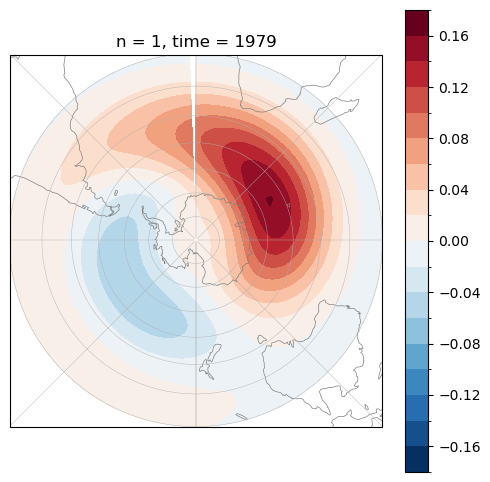

In [95]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = mj_sum.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [56]:
mjeof1 = EOF.sel(n=1)

In [57]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

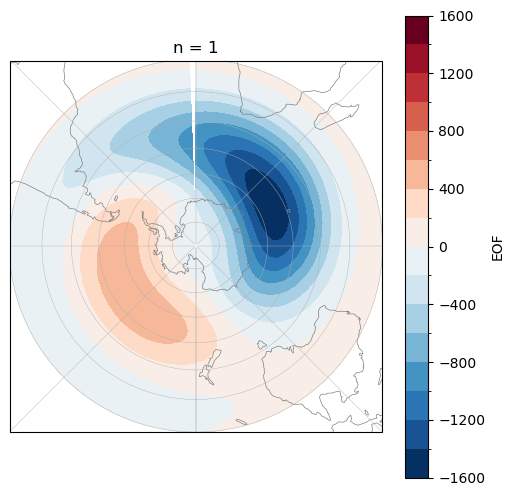

In [58]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = mjeof1.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [130]:
# EOF solver: data are already anomalies → center=False (covariance EOFs)
solver = Eof(da_mon)

# EOFs (mode, lat, lon), PCs (time, mode, unit variance)
eofs = solver.eofs(neofs=1)

In [131]:
eof1 = eofs.sel(mode=0)

In [74]:
pcs  = solver.pcs(npcs=1, pcscaling=0)

In [75]:
pc1_std = pcs.isel(mode=0)

In [76]:
pc1_std

<xarray.DataArray 'pcs' (time: 45)> Size: 180B
array([-4.0107961e+00, -3.2958628e+03, -6.8658771e+02,  2.5985984e+03,
       -6.3670746e+02, -1.6080004e+03,  5.9568403e+03, -4.7371816e+03,
        3.3948087e+02, -2.0102543e+03,  3.6067163e+03,  2.3699702e+03,
       -4.5557007e+03, -1.7475650e+04,  7.5242036e+03, -1.0292438e+04,
        1.6861300e+03, -8.5652197e+03,  5.5254868e+03, -1.0136309e+04,
       -3.0378180e+02,  2.7167554e+03, -1.9128976e+03, -1.7687943e+04,
        2.6029817e+03,  7.2059121e+03, -6.2857783e+03,  8.6299189e+03,
       -2.8733347e+03,  4.6367705e+03,  2.4030513e+03,  5.3730093e+03,
        4.7021606e+03,  3.0645300e+03,  3.6360989e+03, -1.7620201e+03,
        2.9254021e+03, -1.4558014e+03, -2.1010071e+03,  3.9638459e+03,
        4.5230913e+03,  8.1459736e+03,  3.2916208e+03,  3.2967607e+03,
       -2.3388835e+03], dtype=float32)
Coordinates:
  * time     (time) int64 360B 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023
    mode     int64 8B 0

TypeError: bad operand type for unary -: 'GeoContourSet'

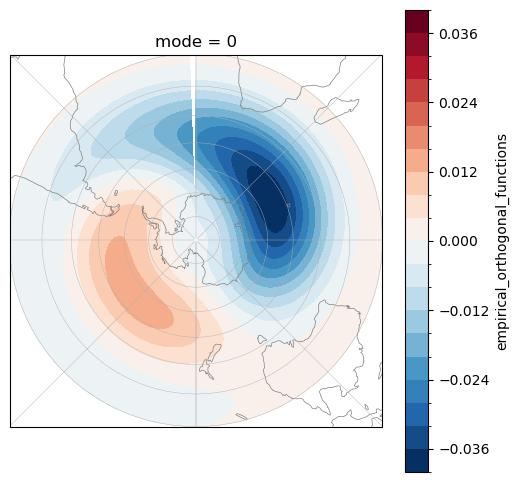

In [147]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = eof1.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [139]:
gh_6h_mon['var129'].groupby("time.day").mean("time")[0]

<xarray.DataArray 'var129' (lat: 36, lon: 180)> Size: 26kB
dask.array<getitem, shape=(36, 180), dtype=float32, chunksize=(36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
    day      int64 8B 1
Attributes:
    table:    128

In [148]:
project = -eof1*gh_6h_mon['var129'].groupby("time.day").mean("time")[0]

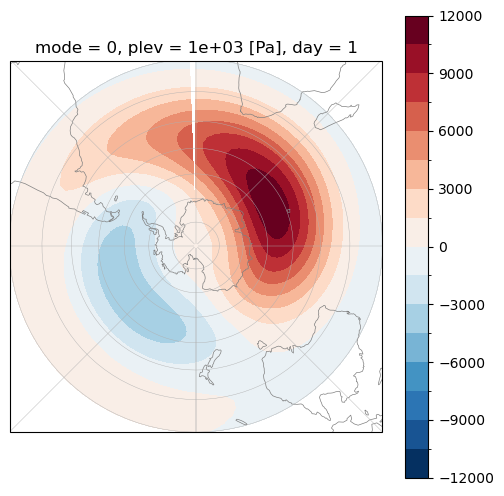

In [149]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = project.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [142]:
month = 6
ilev = 10 # hPa

In [143]:
original_eoff = f"/net/cfc/s2s/rachwu/scripts/sh_ssw_impact/aparc_project/SouthernWarmings_module/data/zeof/ERA5.EOF1.z{ilev}.Mon{month:02d}.nc"

In [144]:
original_eof = xr.open_dataset(original_eoff)['eof1']

In [145]:
projecto = original_eof*gh_6h_mon['var129'].groupby("time.day").mean("time")[0]

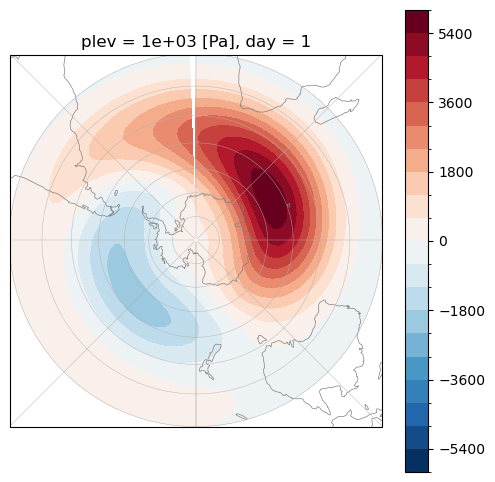

In [146]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = projecto.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [153]:
np.sum(project).values

array(9180000., dtype=float32)

In [154]:
np.sum(projecto).values

array(4575148., dtype=float32)

In [92]:
eofsum = eof1*pc1_std[0]  #+ da_mon.mean('time')

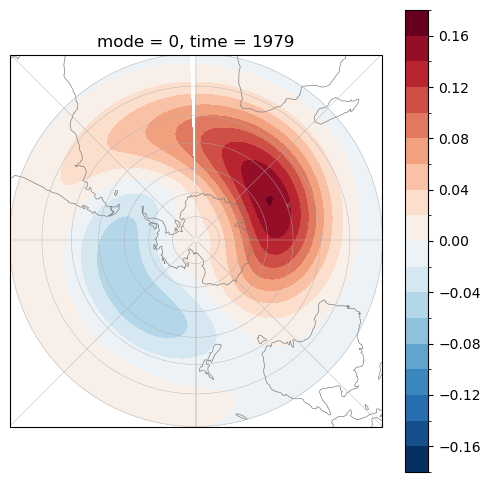

In [93]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = eofsum.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [97]:
mj_sum-eofsum

<xarray.DataArray (lat: 36, lon: 180)> Size: 26kB
array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  2.3283064e-10,  2.3283064e-10],
       [-2.3283064e-10, -2.3283064e-10, -1.1641532e-10, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       ...,
       [-9.3132257e-10, -9.3132257e-10,  0.0000000e+00, ...,
        -9.3132257e-10,  0.0000000e+00,  0.0000000e+00],
       [-4.6566129e-10,  0.0000000e+00, -4.6566129e-10, ...,
         0.0000000e+00,  0.0000000e+00, -4.6566129e-10],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    n        int64 8B 1
    time     int64 8B 1979
    mode     int64 8B 0